# **Denoising**



In [1]:
pip install pesq

  Preparing metadata (setup.py) ... done
  Created wheel for pesq: filename=pesq-0.0.4-cp312-cp312-linux_x86_64.whl size=284120 sha256=94090645ae9bce80111659efb09748415709b8a5f56836797a28749c20d85052
  Stored in directory: /root/.cache/pip/wheels/9b/d4/a4/9cf3512534cd47ce4a036d1593ee4013f2bf7509e631a147a3
Successfully built pesq


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import scipy.special as sp
from scipy.fft import fft, fftfreq
import soundfile as sf
import IPython
import urllib.request
import io
import librosa
import random
import subprocess
from pesq import pesq
import scipy


def add_awgn(clean_signal, snr_db):

    """
    Add Additive White Gaussian Noise (AWGN) to a clean signal at a specified SNR.

    Parameters:
        clean_signal (numpy.ndarray): Clean input signal.
        snr_db (float): Desired Signal-to-Noise Ratio in dB.

    Returns:
        noisy_signal (numpy.ndarray): Noisy signal.
    """
    # Compute signal power
    signal_power = np.mean(clean_signal**2)

    # Convert SNR from dB to linear scale
    snr_linear = 10**(snr_db / 10)

    # Compute noise power
    noise_power = signal_power / snr_linear

    # Generate Gaussian noise
    noise = np.sqrt(noise_power) * np.random.normal(size=clean_signal.shape)

    # Add noise to the clean signal
    noisy_signal = clean_signal + noise

    return noisy_signal


def add_sine(signal, a = 0.05, f = 3000, fs = 16000):

    T = 1/fs
    t = np.arange(0, len(signal)*T, T)

    noisy_signal = signal + a*np.sin(2*np.pi*f*t)

    return noisy_signal


def normalize(signal):

    return signal/np.max(np.abs(signal))


def download_file(url, output_path=None):
    """
    Downloads a file using wget.

    Args:
        url (str): The URL of the file to download.
        output_path (str, optional): The path to save the file. Defaults to the current directory.

    Returns:
        bool: True if download was successful, False otherwise.
    """
    try:
        command = ["wget", url]
        if output_path:
            command.extend(["-O", output_path])  # Add output file path

        # Call wget command
        subprocess.run(command, check=True)

    except subprocess.CalledProcessError as e:
        print(f"Download failed: {e}")



def plot_data(x, y, title = 'Signal', xlabel = 'time (s)', ylabel = 'Amplitude', figsize = (12,3)):
    """
    Plots x vs y with optional title, labels, and style.

    Args:
        x (list or array): Data for the X-axis.
        y (list or array): Data for the Y-axis.
        title (str): Title of the plot.
        xlabel (str): Label for the X-axis.
        ylabel (str): Label for the Y-axis.
        style (str): Line style (default is 'b-' for blue solid line).
    """
    plt.figure(figsize=figsize)
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_spectrogram(wav, fs, window = 'hann', win_duration = 0.005, win_overlap = 0.0025, nfft = 1024, title = 'Spectrogram'):

    f, tt, Sxx = signal.spectrogram(wav, fs, window=window, nperseg=int(win_duration*fs), noverlap=int(win_overlap*fs), nfft=nfft, return_onesided=True)

    plt.figure(figsize=(10,3))
    plt.pcolormesh(tt, f, np.log(Sxx))
    plt.title(title)
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    plt.show()



def load_audio(filename, normalize_data = False):

    wav, fs = sf.read(filename)

    if normalize:
      wav = normalize(wav)

    t = np.arange(0,len(wav)/fs,1/fs)

    return wav, fs, t



def audio_player(wav, fs):

    return IPython.display.Audio(data=wav, rate=fs)



def simple_low_pass_filter(wav, fs, cutoff):

    fft_wav = np.fft.fft(wav)
    fft_freq = np.fft.fftfreq(len(wav), d=1/fs)  # Frequency bins

    fft_wav[np.where(np.abs(fft_freq)>cutoff)] = 0

    return np.fft.ifft(fft_wav).real



def spectral_subtraction(x, fs, win_duration = 20, overlap_perc = 50, VAD_thresh = 3, Expnt = 1.0, G = 0.9, noise_frames = 5, nFFT = 512):

    # calculation parameters
    len_ = win_duration * fs // 1000      # frame size in samples
    len1 = len_ * overlap_perc // 100     # overlop length
    len2 = len_ - len1                    # window length - overlop length
    Nframes = len(x) // len2 - 1


    # initial Hamming window
    win = np.hamming(len_)
    # normalization gain for overlap+add with 50% overlap
    winGain = len2 / sum(win)


    noise_mean = np.zeros(nFFT)


    j = 1
    for k in range(1, noise_frames+1):
        noise_mean = noise_mean + abs(np.fft.fft(win * x[j:j + len_], nFFT))
        j = j + len_
    noise_mu = noise_mean / noise_frames



    k = 1
    x_old = np.zeros(len1)
    xfinal = np.zeros(Nframes * len2)



    # === Start Processing === #
    for n in range(0, Nframes):

        # Windowing
        insign = win * x[k-1:k + len_ - 1]
        # compute fourier transform of a frame
        spec = np.fft.fft(insign, nFFT)
        # compute the magnitude
        sig = abs(spec)
        # save the noisy phase information
        theta = np.angle(spec)
        # SNR
        SNRseg = 10 * np.log10(np.linalg.norm(sig, 2) ** 2 / np.linalg.norm(noise_mu, 2) ** 2)

        # --- spectral subtraction --- #
        sub_speech = sig ** Expnt - noise_mu ** Expnt

        z = np.where(sub_speech<0)

        if len(z) > 0:
            sub_speech[z] = 0

        # # --- implement a simple VAD detector --- #
        # if SNRseg < VAD_thresh:  # Update noise spectrum
        #     noise_temp = G * noise_mu ** Expnt + (1 - G) * sig ** Expnt  # Smoothing processing noise power spectrum
        #     noise_mu = noise_temp ** (1 / Expnt)  # New noise amplitude spectrum

        # add phase
        x_phase = (sub_speech ** (1 / Expnt)) * np.exp(1j * theta)
        # take the IFFT
        xi = np.fft.ifft(x_phase).real

        # --- Overlap and add --- #
        xfinal[k-1:k + len2 - 1] = x_old + xi[0:len1]
        x_old = xi[0 + len1:len_]

        k = k + len2

    return winGain*xfinal



def wiener_filter(x, fs, win_duration = 20, overlap_perc = 50, VAD_thresh = 3, Expnt = 1.0, G = 0.9, noise_frames = 5, nFFT = 512, meladaptive = True):

    # calculation parameters
    len_ = win_duration * fs // 1000      # frame size in samples
    len1 = len_ * overlap_perc // 100   # overlop'length
    len2 = len_ - len1          # window'length - overlop'length


    # sine window
    i = np.linspace(0,len_ - 1,len_)
    win = np.sqrt(2/(len_ + 1)) * np.sin(np.pi * (i + 1) / (len_ + 1))
    win = np.hamming(len_)


    # normalization gain for overlap+add with 50% overlap
    winGain = len2 / sum(win)


    noise_mean = np.zeros(nFFT)

    j = 1
    for k in range(1, noise_frames+1):
        noise_mean = noise_mean + abs(np.fft.fft(win * x[j:j + len_], nFFT))
        j = j + len_
    noise_mu = noise_mean / noise_frames

    # initialize various variables
    k = 1
    img = 1j
    x_old = np.zeros(len1)
    Nframes = len(x) // len2 - 1
    xfinal = np.zeros(Nframes * len2)

    # === Start Processing ==== #
    for n in range(0, Nframes):

        # Windowing
        insign = win * x[k-1:k + len_ - 1]
        # compute fourier transform of a frame
        spec = np.fft.fft(insign, nFFT)
        # compute the magnitude
        sig = abs(spec)
        # save the noisy phase information
        theta = np.angle(spec)
        # Posterior SNR
        SNRpos = 10 * np.log10(np.linalg.norm(sig, 2) ** 2 / np.linalg.norm(noise_mu, 2) ** 2)

        # --- wiener filtering --- #

        # spectral subtraction(Half wave rectification)
        sub_speech = sig ** Expnt - noise_mu ** Expnt

        z = np.where(sub_speech<0)
        if len(z) > 0:
            sub_speech[z] = 0

        # Priori SNR
        SNRpri = 10 * np.log10(np.linalg.norm(sub_speech, 2) ** 2 / np.linalg.norm(noise_mu, 2) ** 2)

        if meladaptive:

            # parameter to deal mel
            mel_max = 10
            mel_0 = (1 + 4 * mel_max) / 5
            s = 25 / (mel_max - 1)
            # deal mel
            def get_mel(SNR):
                if -5.0 <= SNR <= 20.0:
                    a = mel_0 - SNR / s
                else:
                    if SNR < -5.0:
                        a = mel_max
                    if SNR > 20:
                        a = 1
                return a
            # setting mel
            mel = get_mel(SNRpri)

            G_k = sub_speech ** 2 / (sub_speech ** 2 + mel * noise_mu ** 2)

        else:
            G_k = sub_speech ** 2 / (sub_speech ** 2 + noise_mu ** 2)


        wf_speech = G_k * sig

        # # --- implement a simple VAD detector --- #
        # if SNRpos < VAD_thresh:  # Update noise spectrum
        #     noise_temp = G * noise_mu ** Expnt + (1 - G) * sig ** Expnt  # Smoothing processing noise power spectrum
        #     noise_mu = noise_temp ** (1 / Expnt)  # New noise amplitude spectrum

        # add phase
        x_phase = wf_speech * np.exp(img * theta)

        # take the IFFT
        xi = np.fft.ifft(x_phase).real

        # --- Overlap and add --- #
        xfinal[k-1:k + len2 - 1] = x_old + xi[0:len1]
        x_old = xi[0 + len1:len_]

        k = k + len2

    return winGain*xfinal



def mmse_denoiser(x, fs, win_duration = 20, overlap_perc = 50, VAD_thresh = 3, Expnt = 1.0, G = 0.9, noise_frames = 5, nFFT = 512):

    # calculation parameters
    len_ = win_duration * fs // 1000     # frame size in samples
    len1 = len_ * overlap_perc // 100    # overlop'length
    len2 = len_ - len1                   # window'length - overlop'length

    # setting default parameters
    aa = 0.98
    eta = 0.15

    mu = 0.98
    c = np.sqrt(np.pi) / 2
    qk = 0.3
    qkr = (1 - qk) / qk
    ksi_min = 10 ** (-25 / 10)   #-25dB

    # hamming window
    win = np.hamming(len_)
    # normalization gain for overlap+add with 50% overlap
    winGain = len2 / sum(win)


    j = 1
    noise_mean = np.zeros(nFFT)
    for k in range(1, noise_frames+1):
        noise_mean = noise_mean + abs(np.fft.fft(win * x[j : j + len_] , nFFT))
        j = j + len_
    noise_mu = noise_mean / noise_frames
    noise_mu2 = noise_mu ** 2

    # initialize various variables
    k = 1
    img = 1j
    x_old = np.zeros(len2)
    Nframes = len(x) // len2 - 1
    xfinal = np.zeros(Nframes * len2)

    # === Start Processing ==== #
    for n in range(0, Nframes):

        # Windowing
        insign = win * x[k - 1 : k + len_ - 1]

        # Take fourier transform of frame
        spec = np.fft.fft(insign , nFFT)
        sig = abs(spec)
        sig2 = sig ** 2
        # save the noisy phase information
        theta = np.angle(spec)

        SNRpos = 10 * np.log10(np.linalg.norm(sig, 2) ** 2 / np.linalg.norm(noise_mu, 2) ** 2)

        # posteriori SNR
        gammak = np.minimum(sig2 / noise_mu2 , 40)

        # decision-direct estimate of a priori SNR

        if n == 0:
            ksi = aa + (1 - aa) * np.maximum(gammak - 1 , 0)
        else:
            ksi = aa * Xk_prev / noise_mu2 + (1 - aa) * np.maximum(gammak - 1 , 0)
            # limit ksi to -25 dB
            ksi = np.maximum(ksi_min , ksi)

        # # --- implement a simple VAD detector --- #
        # if SNRpos < VAD_thresh:  # Update noise spectrum
        #     noise_mu2 = mu * noise_mu2 + (1 - mu) * sig2  # Smoothing processing noise power spectrum
        #     noise_mu = np.sqrt(noise_mu2)

        vk = gammak * ksi / (1 + ksi)
        # the modified Bessel function of n order iv(n,x)
        j_0 = sp.iv(0 , vk/2) #modified bessel function of the first kind of real order
        j_1 = sp.iv(1 , vk/2)
        C = np.exp(-0.5 * vk)
        A = ((c * (vk ** 0.5)) * C) / gammak      #[7.40] A
        B = (1 + vk) * j_0 + vk * j_1             #[7.40] B
        hw = A * B                                #[7.40]

        # get X(w)
        mmse_speech = hw * sig

        Xk_prev = mmse_speech ** 2

        # IFFT
        x_phase = mmse_speech * np.exp(img * theta)
        xi_w = np.fft.ifft(x_phase , nFFT).real

        # overlop add
        xfinal[k - 1 : k + len2 - 1] = x_old + xi_w[0 : len1]
        x_old = xi_w[len1 + 0 : len_]

        k = k + len2

    return winGain*xfinal






# **Load Speech Signal**

In [3]:
download_file('https://github.com/Tanuka92/SPP_demo_files/raw/main/SX24.WAV', output_path = 'audio.wav')

In [4]:
wav, fs, t = load_audio('audio.wav', normalize_data = True)

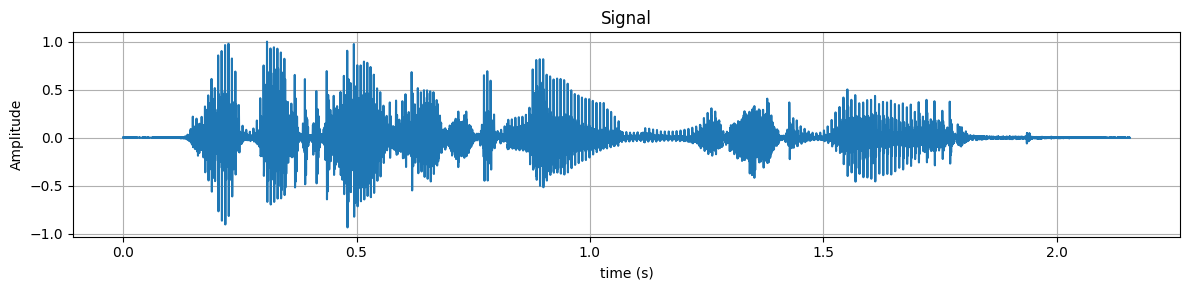

In [5]:
plot_data(t,wav)

audio_player(wav, fs)

# **Add Tonal Noise**

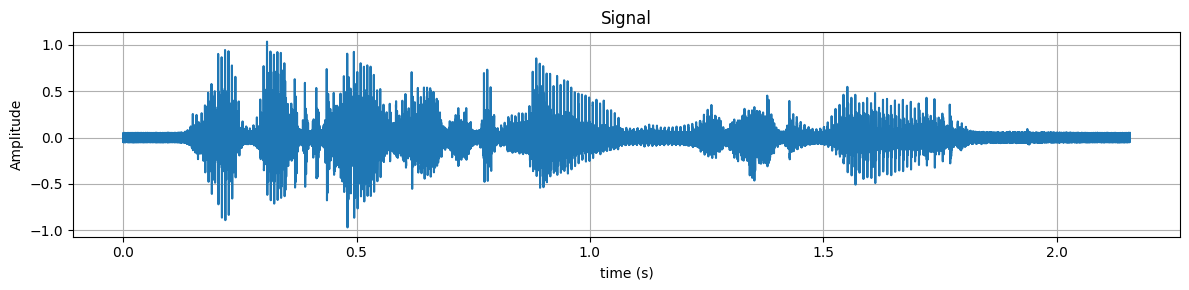

In [6]:
wav_noisy = add_sine(wav)

plot_data(t,wav_noisy)

audio_player(wav_noisy, fs)

# **FFT of the signal**

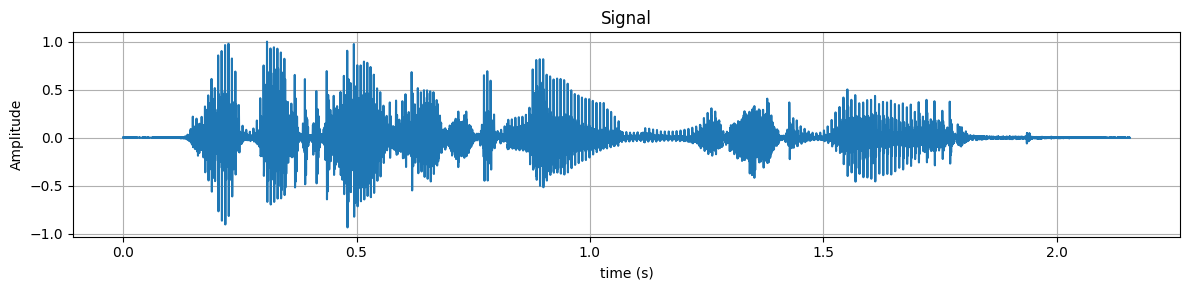

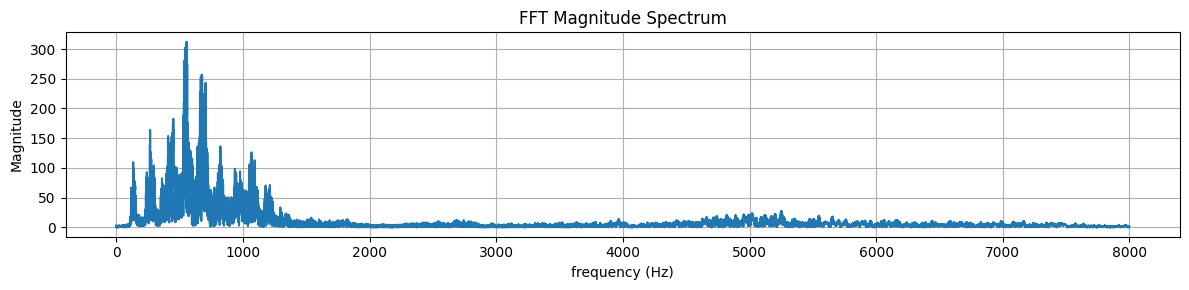

In [7]:
fft_wav = np.fft.fft(wav)
fft_freq = np.fft.fftfreq(len(wav), d=1/fs)  # Frequency bins

magnitude = np.abs(fft_wav)  # Magnitude spectrum
phase = np.angle(fft_wav)  # Phase spectrum

plot_data(t, wav)

plot_data(fft_freq[:len(fft_freq)//2], magnitude[:len(fft_freq)//2], title = 'FFT Magnitude Spectrum', xlabel = 'frequency (Hz)', ylabel = 'Magnitude')

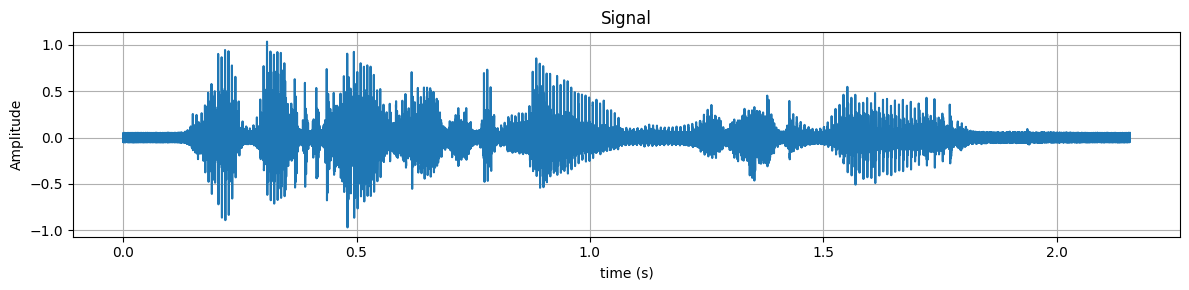

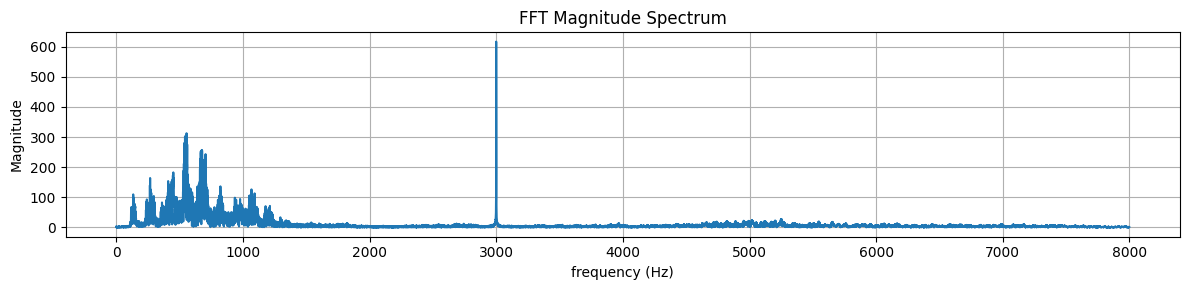

In [8]:
fft_wav = np.fft.fft(wav_noisy)
fft_freq = np.fft.fftfreq(len(wav_noisy), d=1/fs)  # Frequency bins

magnitude = np.abs(fft_wav)  # Magnitude spectrum
phase = np.angle(fft_wav)  # Phase spectrum

plot_data(t, wav_noisy)

plot_data(fft_freq[:len(fft_freq)//2], magnitude[:len(fft_freq)//2], title = 'FFT Magnitude Spectrum', xlabel = 'frequency (Hz)', ylabel = 'Magnitude')

In [9]:
IPython.display.Audio(data=wav_noisy, rate=fs)

# **Simple Low Pass Filtering**

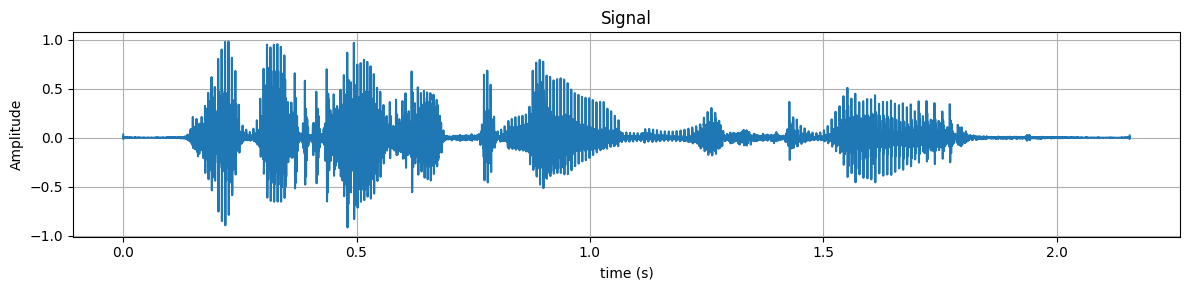

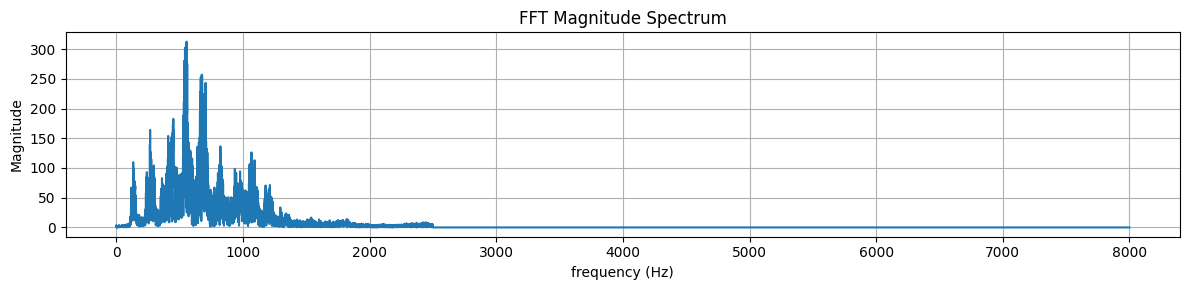

In [10]:
wav_filtered = simple_low_pass_filter(wav_noisy, fs, cutoff = 2500)

fft_wav = np.fft.fft(wav_filtered)
fft_freq = np.fft.fftfreq(len(wav_filtered), d=1/fs)  # Frequency bins

magnitude = np.abs(fft_wav)  # Magnitude spectrum
phase = np.angle(fft_wav)  # Phase spectrum

plot_data(t, wav_filtered)

plot_data(fft_freq[:len(fft_freq)//2], magnitude[:len(fft_freq)//2], title = 'FFT Magnitude Spectrum', xlabel = 'frequency (Hz)', ylabel = 'Magnitude')

audio_player(wav_filtered, fs)

# **Add AWGN noise**

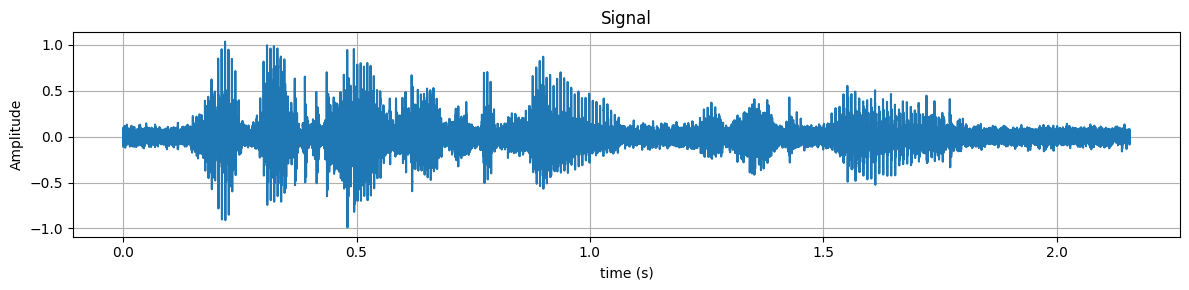

In [12]:
snr_db = 10  # noise level

wav_noisy_awgn = add_awgn(wav, snr_db)

plot_data(t, wav_noisy_awgn)

audio_player(wav_noisy_awgn, fs)

In [13]:
import scipy.io.wavfile
scipy.io.wavfile.write('wav_noisy_awgn.wav', fs, wav_noisy_awgn)

# **Spectral Subtraction**

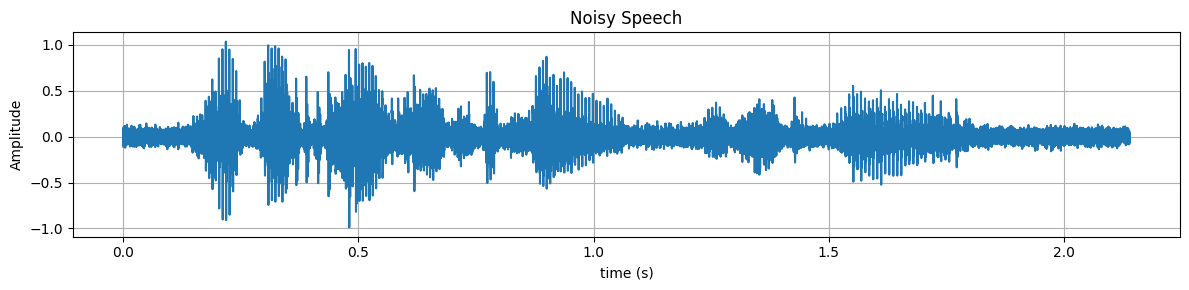

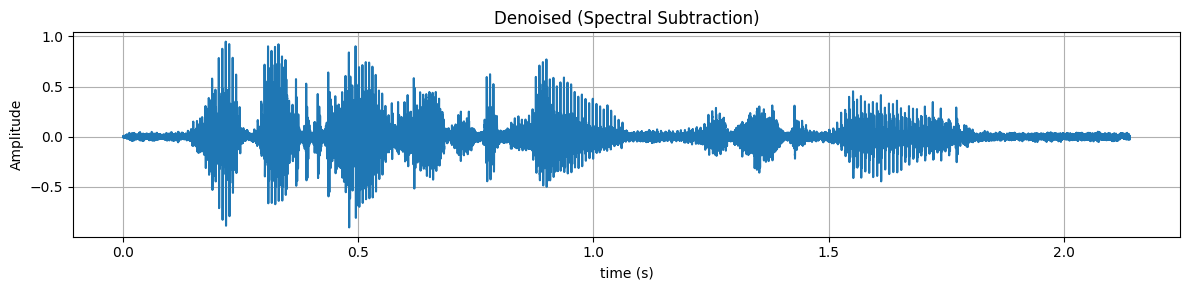

In [14]:
xd = spectral_subtraction(wav_noisy_awgn,fs)

plot_data(t[:len(xd)],wav_noisy_awgn[:len(xd)], title = 'Noisy Speech')

plot_data(t[:len(xd)],xd, title = 'Denoised (Spectral Subtraction)')

In [15]:
audio_player(wav_noisy_awgn, fs)

In [16]:
audio_player(xd, fs)

# **Wiener Filter**



Let the observed noisy speech signal $y(t)$ be expressed as:

$$
y(t) = s(t) + n(t)
$$

where:
$s(t)$: Clean speech signal.
$n(t)$: Additive noise.


The goal of the Wiener filter is to find the linear filter $h(t)$ which when applied to $y(t)$ produces $s(t)$ from $y(t)$ in the frequency domain.

Taking the Fourier transform:
$$
Y(f) = S(f) + N(f)
$$
where $Y(f)$, $S(f)$, and $N(f)$ are the Fourier transforms of $y(t)$, $s(t)$, and $n(t)$, respectively.

The Wiener filter estimates $S(f)$ as:
$$
\hat{S}(f) = H(f) Y(f)
$$
where $H(f)$ is the Wiener filter transfer function.



The Wiener filter minimizes the mean squared error (MSE):
$$
\text{MSE} = \mathbb{E} \left[ |S(f) - \hat{S}(f)|^2 \right]
$$

Substituting $\hat{S}(f) = H(f) Y(f)$:
$$
\text{MSE} = \mathbb{E} \left[ |S(f) - H(f)Y(f)|^2 \right]
$$

Expanding:

$$
\text{MSE} = \mathbb{E} \left[ |S(f)|^2 \right] - 2 \text{Re} \left\{ H(f) \mathbb{E} \left[ S(f) Y^*(f) \right] \right\} + |H(f)|^2 \mathbb{E} \left[ |Y(f)|^2 \right]
$$

To minimize MSE, differentiate with respect to $H(f)$ and set to zero:

$$
\frac{\partial \text{MSE}}{\partial H(f)} = -2 \mathbb{E} \left[ S(f) Y^*(f) \right] + 2 H(f) \mathbb{E} \left[ |Y(f)|^2 \right] = 0
$$

Rearranging:
$$
H(f) = \frac{\mathbb{E} \left[ S(f) Y^*(f) \right]}{\mathbb{E} \left[ |Y(f)|^2 \right]}
$$

Let:
$$
\mathbb{E} \left[ S(f) Y^*(f) \right] = \Phi_{SY}(f), \quad \mathbb{E} \left[ |Y(f)|^2 \right] = \Phi_{YY}(f)
$$

where:

$\Phi_{SY}(f)$: Cross power spectral density of $S(f)$ and $Y(f)$.
$\Phi_{YY}(f)$: Power spectral density of $Y(f)$.


Thus:
$$
H(f) = \frac{\Phi_{SY}(f)}{\Phi_{YY}(f)}
$$


Assume:
$\Phi_{YY}(f) = \Phi_{SS}(f) + \Phi_{NN}(f)$

$\Phi_{SS}(f)$: Power spectral density of the clean speech.
$\Phi_{NN}(f)$: Power spectral density of the noise.


Assume $\Phi_{SY}(f) = \Phi_{SS}(f)$. Then:
$$
H(f) = \frac{\Phi_{SS}(f)}{\Phi_{SS}(f) + \Phi_{NN}(f)}
$$

Define the a priori signal-to-noise ratio (SNR) as:
$$
\text{SNR}(f) = \frac{\Phi_{SS}(f)}{\Phi_{NN}(f)}
$$

Substitute:
$$
H(f) = \frac{\text{SNR}(f)}{\text{SNR}(f) + 1}
$$

The estimated clean speech spectrum is:
$$
\hat{S}(f) = H(f) Y(f)
$$

To reconstruct the enhanced speech in the time domain:
Apply $H(f)$ to $Y(f)$ in the frequency domain.
Compute the inverse Fourier transform:

$\hat{s}(t) = \mathcal{F}^{-1} \{ \hat{S}(f) \}$

Estimate power spectral densities $\Phi_{SS}(f)$, $\Phi_{NN}(f)$, or SNR.
Compute the Wiener filter:
$
    H(f) = \frac{\text{SNR}(f)}{\text{SNR}(f) + 1}
$
Apply $H(f)$ to the noisy signal $Y(f)$.
Perform an inverse Fourier transform to obtain the enhanced speech signal.



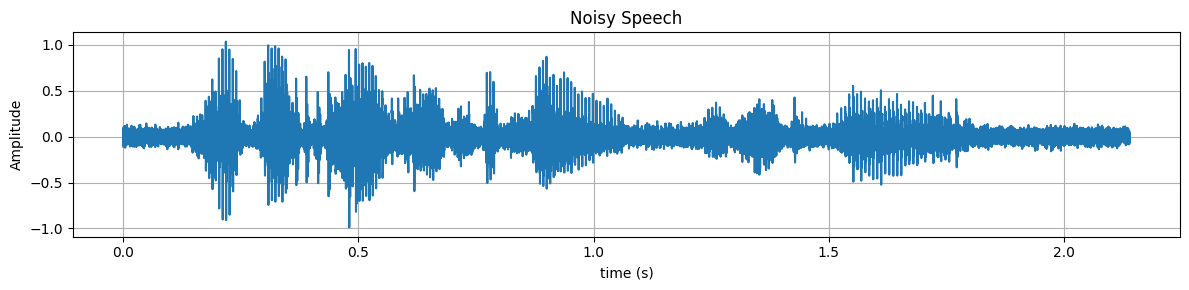

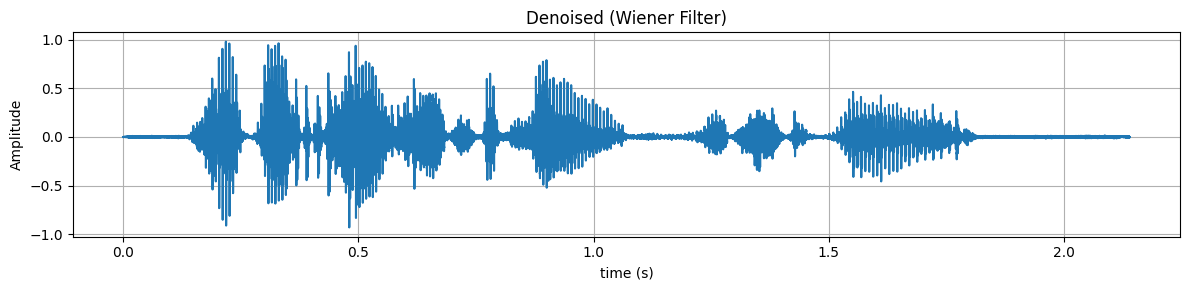

In [17]:
xw = wiener_filter(wav_noisy_awgn, fs)

plot_data(t[:len(xw)],wav_noisy_awgn[:len(xw)], title = 'Noisy Speech')

plot_data(t[:len(xw)],xw, title = 'Denoised (Wiener Filter)')



In [18]:
audio_player(wav_noisy_awgn, fs)

In [19]:
audio_player(xw, fs)

# **MMSE**

Given the value of the noisy spectrum $Y_{k}$ where k is the frequency index. What is the best estimate $f(Y_{k}) = \hat X_{k}$ of the clean value $X_{k}$?

What is $f(Y_k)$?

In the MSE sense, this is equivalent to the function that minimizes $\mathbb{E}[\|X_{k}-f(Y_{k})\|^2]$

$\hat X_k = f(Y_{k}) = \mathbb{E}[X_{k}|Y_{k}]$




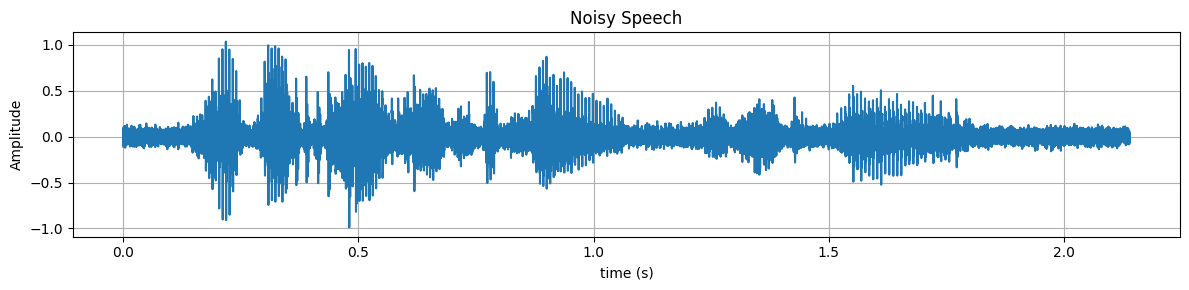

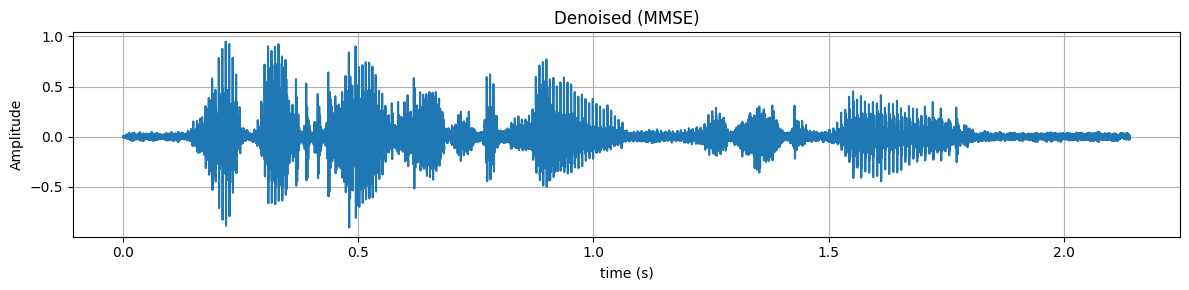

In [20]:
xm = mmse_denoiser(wav_noisy_awgn, fs)

plot_data(t[:len(xd)],wav_noisy_awgn[:len(xd)], title = 'Noisy Speech')

plot_data(t[:len(xd)],xd, title = 'Denoised (MMSE)')

In [21]:
audio_player(wav_noisy_awgn, fs)

In [22]:
audio_player(xm, fs)

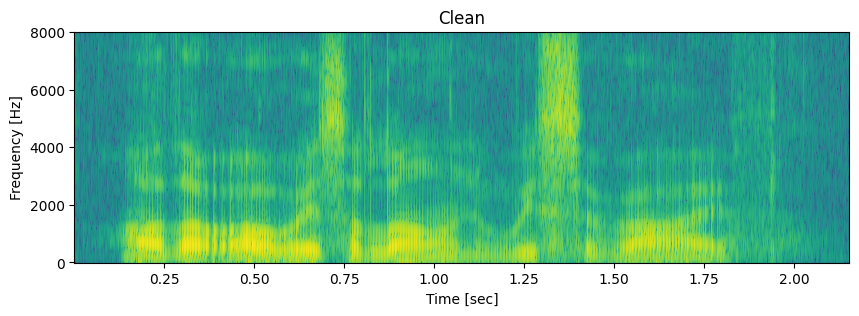

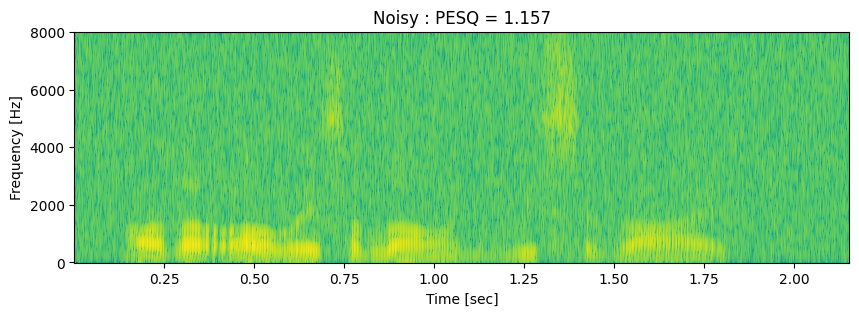

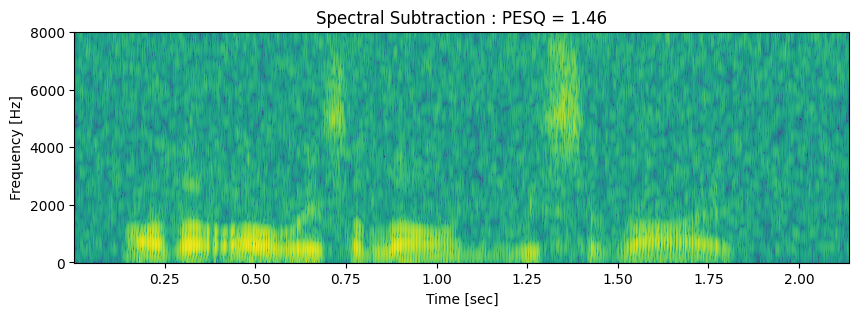

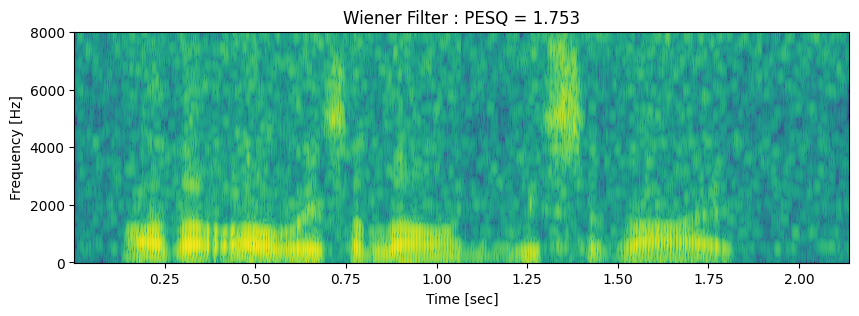

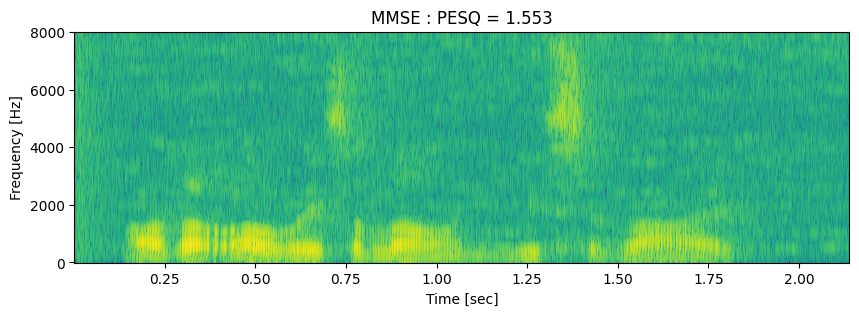

In [23]:
plot_spectrogram(wav, fs, title = 'Clean')
plot_spectrogram(wav_noisy_awgn, fs, title = 'Noisy : PESQ = '+str(np.round(pesq(fs, wav, wav_noisy_awgn, 'wb'),3)))
plot_spectrogram(xd, fs, title = 'Spectral Subtraction : PESQ = '+str(np.round(pesq(fs, wav, xd, 'wb'),3)))
plot_spectrogram(xw, fs, title = 'Wiener Filter : PESQ = '+str(np.round(pesq(fs, wav, xw, 'wb'),3)))
plot_spectrogram(xm, fs, title = 'MMSE : PESQ = '+str(np.round(pesq(fs, wav, xm, 'wb'),3)))

# **Classification**

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

import os
import glob
from tqdm import tqdm


def load_gender_split_data():
    !wget -O 'gender_classify.zip' 'https://github.com/Tanuka92/SPP_demo_files/raw/main/gender_classify.zip'
    !unzip -o gender_classify.zip


def load_noises():
    os.makedirs('noises', exist_ok=True)

    !wget -O 'noises/white.wav' 'https://github.com/Tanuka92/SPP_demo_files/raw/main/white_full.wav'
    !wget -O 'noises/pink.wav' 'https://github.com/Tanuka92/SPP_demo_files/raw/main/pink_full.wav'
    !wget -O 'noises/factory.wav' 'https://github.com/Tanuka92/SPP_demo_files/raw/main/factory_full.wav'
    !wget -O 'noises/speech_babble.wav' 'https://github.com/Tanuka92/SPP_demo_files/raw/main/machinegun_full.wav'
    !wget -O 'noises/machine_gun.wav' 'https://github.com/Tanuka92/SPP_demo_files/raw/main/speech_babble_full.wav'


def add_noise(speechdir_path, noise_type, snr, fs=16000):

    output_audiodir_path = speechdir_path + '_' + noise_type + '_' +str(snr) +'db'
    os.makedirs(output_audiodir_path, exist_ok=True)

    if noise_type == 'awgn':
        for ff in tqdm(glob.glob(speechdir_path + '/*')):
            clean, _ = librosa.load(ff, sr=fs)
            # Use the pre-defined add_awgn function for Additive White Gaussian Noise
            noisy_audio = add_awgn(clean, snr)
            scipy.io.wavfile.write(output_audiodir_path + '/' + os.path.basename(ff), fs, noisy_audio)
    else:
        noise, _, _ = load_audio('noises/'+noise_type+'.wav')

        for ff in tqdm(glob.glob(speechdir_path + '/*')):

            clean, _ = librosa.load(ff, sr=fs)

            noise_start_idx = np.random.randint(0, noise.size-clean.size)
            noise_seg = noise[noise_start_idx:noise_start_idx+clean.size]

            # Calculate noise scaling factor based on SNR
            snr_linear = 10 ** (snr / 10)
            noise_power = np.mean(noise_seg**2)
            clean_power = np.mean(clean**2)
            noise_factor = np.sqrt((clean_power / noise_power) / snr_linear)

            # Scale noise and add to clean audio
            noise_seg = noise_seg * noise_factor
            noisy_audio = clean + noise_seg

            # Save mixed audio
            scipy.io.wavfile.write(output_audiodir_path + '/' + os.path.basename(ff), fs, noisy_audio)


def denoise(speechdir_path, fs=16000, denoiser = 'wiener'):

    output_audiodir_path = speechdir_path + '_' + denoiser + '_denoised'
    os.makedirs(output_audiodir_path, exist_ok=True)

    # print(speechdir_path)

    for ff in tqdm(glob.glob(speechdir_path + '/*')):

        noisy, _ = librosa.load(ff, sr=fs)

        if np.char.equal(denoiser, 'wiener'):
            denoised = wiener_filter(noisy, 16000)

        if np.char.equal(denoiser, 'spectral_subtraction'):
            denoised = spectral_subtraction(noisy, 16000)

        if np.char.equal(denoiser, 'mmse'):
            denoised = mmse_denoiser(noisy, 16000)

        scipy.io.wavfile.write(output_audiodir_path + '/' + os.path.basename(ff), fs, denoised)


def get_spec(dirpath, fs=16000):

    x = []
    y = []

    for ff in glob.glob(dirpath + '/*'):
        wav, _ = librosa.load(ff, sr=fs)

        wav = (wav - np.mean(wav))/np.std(wav)

        f, tt, Sxx = signal.spectrogram(wav, fs,
                                        window='hann',
                                        nperseg=int(0.02*fs),
                                        noverlap=int(0.01*fs),
                                        return_onesided=True)

        x.append(np.mean(Sxx, axis=-1))
        y.append(os.path.basename(ff)[0])

    x = np.array(x)
    y = np.array(y)

    return x, y


def train_test_svm(traindir_path, testdir_path):

    x_train, y_train = get_spec(traindir_path)
    x_test, y_test = get_spec(testdir_path)

    clf = SVC(random_state=0)
    clf.fit(x_train, y_train)

    y_pred = clf.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    con_mat = confusion_matrix(y_test, y_pred)

    print(f'Test accuracy: {acc}')
    print(f'Confusion matrix: \n {con_mat}')

In [25]:
load_gender_split_data()


--2026-01-21 09:58:13--  https://github.com/Tanuka92/SPP_demo_files/raw/main/gender_classify.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Tanuka92/SPP_demo_files/main/gender_classify.zip [following]
--2026-01-21 09:58:13--  https://raw.githubusercontent.com/Tanuka92/SPP_demo_files/main/gender_classify.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23289325 (22M) [application/zip]
Saving to: ‘gender_classify.zip’

gender_classify.zip 100%[===================>]  22.21M  --.-KB/s    in 0.1s    

2026-01-21 09:58:14 (185 MB/s) - ‘gender_classify.zip’ saved [23289325/23289325]

Archive:  

In [26]:
load_noises()

--2026-01-21 09:58:30--  https://github.com/Tanuka92/SPP_demo_files/raw/main/white_full.wav
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Tanuka92/SPP_demo_files/main/white_full.wav [following]
--2026-01-21 09:58:31--  https://raw.githubusercontent.com/Tanuka92/SPP_demo_files/main/white_full.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7527418 (7.2M) [audio/wav]
Saving to: ‘noises/white.wav’

noises/white.wav    100%[===================>]   7.18M  --.-KB/s    in 0.08s   

2026-01-21 09:58:31 (90.8 MB/s) - ‘noises/white.wav’ saved [7527418/7527418]

--2026-01-21 09:58:31--  https://githu

In [27]:
snr = -10

noise_type = 'awgn'

add_noise('gender_classify/test', noise_type, snr)
denoise('gender_classify/test_'+noise_type+'_'+ str(snr)+'db', denoiser = 'spectral_subtraction')
denoise('gender_classify/test_'+noise_type+'_'+ str(snr)+'db', denoiser = 'wiener')
denoise('gender_classify/test_'+noise_type+'_'+ str(snr)+'db', denoiser = 'mmse')

100%|██████████| 19/19 [00:03<00:00,  5.19it/s]


In [28]:
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db')

denoiser = 'spectral_subtraction'
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db_'+denoiser+'_denoised')
denoiser = 'wiener'
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db_'+denoiser+'_denoised')
denoiser = 'mmse'
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db_'+denoiser+'_denoised')

Test accuracy: 0.8421052631578947
Confusion matrix: 
 [[11  0]
 [ 3  5]]
Test accuracy: 0.8947368421052632
Confusion matrix: 
 [[11  0]
 [ 2  6]]
Test accuracy: 0.9473684210526315
Confusion matrix: 
 [[11  0]
 [ 1  7]]
Test accuracy: 1.0
Confusion matrix: 
 [[11  0]
 [ 0  8]]


In [29]:
snr = -5

noise_type = 'pink'

add_noise('gender_classify/test', noise_type, snr)
denoise('gender_classify/test_'+noise_type+'_'+ str(snr)+'db', denoiser = 'spectral_subtraction')
denoise('gender_classify/test_'+noise_type+'_'+ str(snr)+'db', denoiser = 'wiener')
denoise('gender_classify/test_'+noise_type+'_'+ str(snr)+'db', denoiser = 'mmse')

100%|██████████| 19/19 [00:04<00:00,  4.16it/s]


In [30]:
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db')

denoiser = 'spectral_subtraction'
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db_'+denoiser+'_denoised')
denoiser = 'wiener'
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db_'+denoiser+'_denoised')
denoiser = 'mmse'
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db_'+denoiser+'_denoised')

Test accuracy: 0.5263157894736842
Confusion matrix: 
 [[2 9]
 [0 8]]
Test accuracy: 0.9473684210526315
Confusion matrix: 
 [[10  1]
 [ 0  8]]
Test accuracy: 0.8947368421052632
Confusion matrix: 
 [[11  0]
 [ 2  6]]
Test accuracy: 1.0
Confusion matrix: 
 [[11  0]
 [ 0  8]]


In [31]:
snr = -5

noise_type = 'factory'

add_noise('gender_classify/test', noise_type, snr)
denoise('gender_classify/test_'+noise_type+'_'+ str(snr)+'db', denoiser = 'spectral_subtraction')
denoise('gender_classify/test_'+noise_type+'_'+ str(snr)+'db', denoiser = 'wiener')
denoise('gender_classify/test_'+noise_type+'_'+ str(snr)+'db', denoiser = 'mmse')

 63%|██████▎   | 12/19 [00:00<00:00, 11.52it/s]/tmp/ipython-input-2133916940.py:282: RuntimeWarning: divide by zero encountered in log10
  SNRpri = 10 * np.log10(np.linalg.norm(sub_speech, 2) ** 2 / np.linalg.norm(noise_mu, 2) ** 2)
100%|██████████| 19/19 [00:04<00:00,  4.69it/s]


In [32]:
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db')

denoiser = 'spectral_subtraction'
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db_'+denoiser+'_denoised')
denoiser = 'wiener'
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db_'+denoiser+'_denoised')
denoiser = 'mmse'
train_test_svm('gender_classify/train', 'gender_classify/test_'+noise_type+'_'+str(snr)+'db_'+denoiser+'_denoised')

Test accuracy: 0.7368421052631579
Confusion matrix: 
 [[6 5]
 [0 8]]
Test accuracy: 0.7894736842105263
Confusion matrix: 
 [[7 4]
 [0 8]]
Test accuracy: 0.8947368421052632
Confusion matrix: 
 [[10  1]
 [ 1  7]]
Test accuracy: 0.8947368421052632
Confusion matrix: 
 [[9 2]
 [0 8]]
